In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

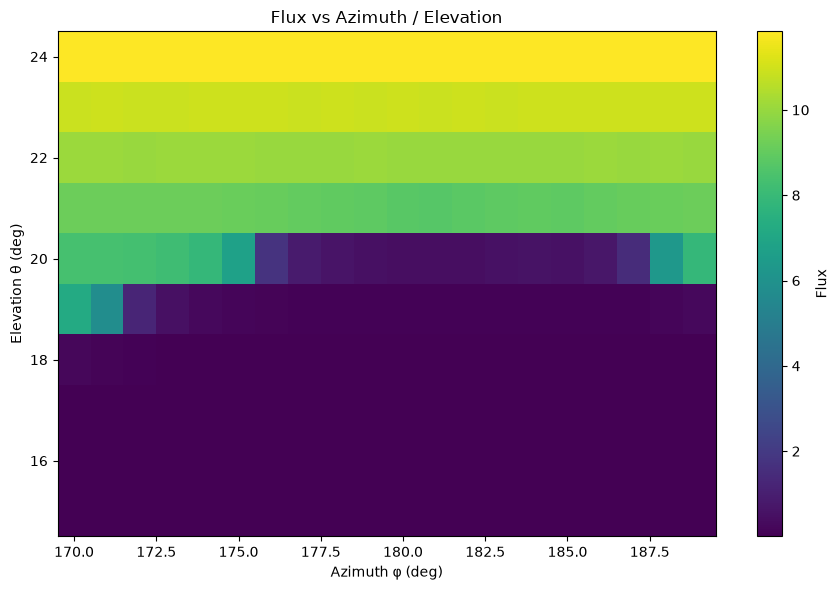

In [5]:
# --- Load data ---
# Columns: azimuth (phi), elevation (theta), flux, std (ignored), n_events (ignored)
filename = "relativeApproach/condor_parts/flux_5m_02bin_rho2650.0_discrete_200T_170-190_15-25.txt"  # <-- change this to your file path

df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["phi", "theta", "flux", "std", "n_events"],
)

# --- Pivot into a 2D grid: rows = theta, cols = phi ---
grid = df.pivot(index="theta", columns="phi", values="flux")

phi_vals = grid.columns.values      # x-axis
theta_vals = grid.index.values      # y-axis
flux_grid = grid.values             # 2D array, shape (n_theta, n_phi)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

# pcolormesh needs bin edges, not centers, for correct cell placement.
# If your phi/theta values are on a regular 1-degree grid, this adds
# half-a-bin padding on each side so cells are centered on their values.
def edges_from_centers(centers):
    centers = np.sort(centers)
    step = np.diff(centers).mean() if len(centers) > 1 else 1.0
    return np.concatenate([centers - step / 2, [centers[-1] + step / 2]])

phi_edges = edges_from_centers(phi_vals)
theta_edges = edges_from_centers(theta_vals)

mesh = ax.pcolormesh(
    phi_edges, theta_edges, flux_grid,
    shading="flat", cmap="viridis"
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Flux")

ax.set_xlabel("Azimuth φ (deg)")
ax.set_ylabel("Elevation θ (deg)")
ax.set_title("Flux vs Azimuth / Elevation")

plt.tight_layout()
plt.savefig("flux_map.png", dpi=200)
plt.show()